In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, DataLoader
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:
transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

torch.Size([60000, 28, 28])
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,

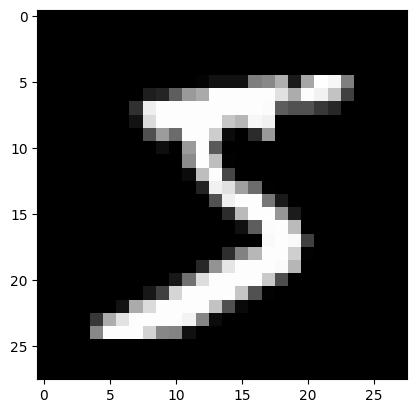

In [19]:
print(train_dataset.data.shape)
# 첫번째 데이터 출력
print(train_dataset.data[0])
# matplot 으로 출력
plt.imshow(train_dataset.data[0], cmap='gray')
print(train_dataset.targets[0])
plt.show()

In [20]:
class Encoder(nn.Module):
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super(Encoder, self).__init__()
    self.encoder_cnn = nn.Sequential(
        nn.Conv2d(1, 8, 3, stride=2, padding=1),
        nn.ReLU(True),
        nn.Conv2d(8, 16, 3, stride=2, padding=1),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.Conv2d(16, 32, 3, stride=2, padding=0),
        nn.ReLU(True)
    )
    self.flatten = nn.Flatten(start_dim=1)
    self.encoder_lin = nn.Sequential(
        nn.Linear(3 * 3 * 32, 128),
        nn.ReLU(True),
        nn.Linear(128, encoded_space_dim)
    )
  def forward(self, x):
    x = self.encoder_cnn(x)
    x = self.flatten(x)
    x = self.encoder_lin(x)
    return x

class Decoder(nn.Module):
  def __init__(self, encoded_space_dim, fc2_input_dim):
    super(Decoder, self).__init__()
    self.decoder_lin = nn.Sequential(
        nn.Linear(encoded_space_dim, 128),
        nn.ReLU(True),
        nn.Linear(128, 3 * 3 * 32),
        nn.ReLU(True)
    )
    self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))
    self.decoder_conv = nn.Sequential(
        nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
        nn.BatchNorm2d(16),
        nn.ReLU(True),
        nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
        nn.BatchNorm2d(8),
        nn.ReLU(True),
        nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1)
    )
  def forward(self, x):
    x = self.decoder_lin(x)
    x = self.unflatten(x)
    x = self.decoder_conv(x)
    x = torch.sigmoid(x)
    return x


In [21]:
encoder = Encoder(encoded_space_dim=2, fc2_input_dim=128)
decoder = Decoder(encoded_space_dim=2, fc2_input_dim=128)
encoder.to(device)
decoder.to(device)

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()}
]

optimizer = optim.Adam(params_to_optimize, lr=0.001, weight_decay=1e-05)
loss_fn = nn.MSELoss()

In [22]:
def add_noise(inputs, noise_factor=0.3):
  noisy = inputs + torch.randn_like(inputs) * noise_factor
  noisy = torch.clip(noisy, 0., 1.)
  return noisy

In [23]:
def plot_ae_outputs(encoder, decoder, n=15, noise_factor=0.3):
  plt.figure(figsize=(10,4.5))
  for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    img = test_dataset.data[i][0].unsqueeze(0).float().to(device)
    noisy_img = add_noise(img, noise_factor).to(device)
    encoder.eval()
    decoder.eval()
    with torch.no_grad():
      rec_img = decoder(encoder(noisy_img))
    plt.imshow(img.cpu().squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('Original images')
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(noisy_img.cpu().squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('Noisy Input')

    ax = plt.subplot(3, n, i + 1 + n * 2)
    plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    if i == n//2:
      ax.set_title('Reconstructed Input')
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.7, top=0.9, wspace=0.3, hspace=0.3)
  plt.show()

In [24]:
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer, noise_factor=0.3):
  encoder.train()
  decoder.train()
  train_loss = []
  for image_batch, _ in dataloader:
    image_batch = image_batch.to(device)
    noisy_batch = add_noise(image_batch, noise_factor)
    encoded_data = encoder(noisy_batch)
    decoded_data = decoder(encoded_data)
    loss = loss_fn(decoded_data, image_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss.append(loss.detach().cpu().numpy())
  return np.mean(train_loss)

In [25]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn, noise_factor=0.3):
  encoder.eval()
  decoder.eval()
  with torch.no_grad():
    conc_out = []
    conc_label = []
    for image_batch, _ in dataloader:
      image_batch = image_batch.to(device)
      noisy_batch = add_noise(image_batch, noise_factor)
      encoded_data = encoder(noisy_batch)
      decoded_data = decoder(encoded_data)
      conc_out.append(decoded_data.cpu())
      conc_label.append(image_batch.cpu())
    conc_out = torch.cat(conc_out)
    conc_label = torch.cat(conc_label)
    val_loss = loss_fn(conc_out, conc_label)
  return val_loss.data

EPOCHE 1/30

 EPOCH 1/30 	 train loss 0.061 	 val loss 0.045


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 28]

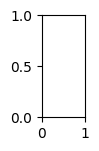

In [26]:
num_epochs = 30
history_da = {'train_loss':[], 'test_loss':[]}
loss_fn = nn.MSELoss()
for epoch in range(num_epochs):
  print('EPOCHE %d/%d' % (epoch + 1, num_epochs))
  train_loss = train_epoch(
      encoder=encoder,
      decoder=decoder,
      device=device,
      dataloader=train_loader,
      loss_fn=loss_fn,
      optimizer=optimizer,
      noise_factor=0.3
  )
  val_loss = test_epoch(
      encoder=encoder,
      decoder=decoder,
      device=device,
      dataloader=test_loader,
      loss_fn=loss_fn,
      noise_factor=0.3
  )
  history_da['train_loss'].append(train_loss)
  history_da['test_loss'].append(val_loss)
  print('\n EPOCH {}/{} \t train loss {:.3f} \t val loss {:.3f}'.format(epoch + 1, num_epochs, train_loss, val_loss))
  plot_ae_outputs(encoder=encoder, decoder=decoder, noise_factor=0.3)